In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
sys.path.insert(0, "../..")

from src.model import MonotonicNN
from src.schemas import OptimizerParams
from src.utils import get_best_f1, calculate_brier_metrics, ice_pdp_plot_xgb_or_nn
from src.calibration.calibration_plots import calibration_diagnostics
from src.calibration.calibrator import Calibrator

## Load and EDA

In [2]:
# Dataset creation
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

df = data['data'].copy()
df['target'] = data['target']

# 1=malignant, 0=benign
df['target'] = df['target'] + 1
df.loc[df['target'] == 2, 'target'] = 0

In [3]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [4]:
# Separate target
y = df["target"].values.astype(np.float32)
X = df.drop(columns=["target"])

In [5]:
ir_tr = float((y == 0).sum() / (y == 1).sum())
n0, n1 = (y == 0).sum(), (y == 1).sum()
mayoritary_label = 0.0 if n0 >= n1 else 1.0

print(f"Imbalance Ratio: {ir_tr:.2f} (n0={n0}, n1={n1})")

Imbalance Ratio: 1.68 (n0=357, n1=212)


In [6]:
# Train / validation / test split
x_tr, x_val_test, y_tr, y_val_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
x_val, x_test, y_val, y_test = train_test_split(
    x_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test
)

# Standardize features
scaler = StandardScaler()
x_tr_std = scaler.fit_transform(x_tr)
x_val_std = scaler.transform(x_val)
x_test_std = scaler.transform(x_test)

## Init and fit the model

In [7]:
# Convert to PyTorch tensors
x_tr_t = torch.tensor(x_tr_std, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)

x_val_t = torch.tensor(x_val_std, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

x_test_t = torch.tensor(x_val_std, dtype=torch.float32)
y_test_t = torch.tensor(y_val, dtype=torch.float32)

In [8]:
# Define the NN
all_vars = list(x_tr.columns)  # must match column order
non_mon_vars = ['mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity',
 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error',
 'area error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error',
 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
pos_mon_vars = ["mean radius"]
neg_mon_vars = ["smoothness error"]

model = MonotonicNN(
    all_variables=all_vars,
    non_monotonic_vars=non_mon_vars,
    positive_monotonic_vars=pos_mon_vars,
    negative_monotonic_vars=neg_mon_vars,
    hidden_non=16,
    hidden_pos=8,
    hidden_neg=8
)

In [9]:
# Fit the model
history = model.fit(
    x_tr=x_tr_t,
    y_tr=y_tr_t,
    x_val=x_val_t,
    y_val=y_val_t,
    pos_weight=1.0,
    epochs=100,
    optimizer_params=OptimizerParams(
        lr=1e-3,
        weight_decay=1e-5,
        batch_size=256,
        patience=5
    ),
    device="cpu",   # or "cuda" if available
    verbose=True
)

Epoch 1/100:   0%|          | 0/2 [00:00<?, ?batch/s, loss=0.7911]

Epoch 1 | Train: 0.80935 | Val: 1.09337


Epoch 2 | Train: 0.78902 | Val: 1.05738


Epoch 3/100:   0%|          | 0/2 [00:00<?, ?batch/s, loss=0.8503]

Epoch 3 | Train: 0.77650 | Val: 1.02239


...

Epoch 97 | Train: 0.16784 | Val: 0.26668


Epoch 98 | Train: 0.15544 | Val: 0.26506


Epoch 99/100:   0%|          | 0/2 [00:00<?, ?batch/s, loss=0.1863]

Epoch 99 | Train: 0.16514 | Val: 0.26347


Epoch 100 | Train: 0.15173 | Val: 0.26187


## Model evaluation

In [27]:
# Predict probs on validation set
probs_tr = model.predict_proba(x_tr_std)
probs_val = model.predict_proba(x_val_std)
probs_test = model.predict_proba(x_test_std)

# Compute best threshold & F1
best_t_tr, best_f1_tr, f1_tr_curve, thresholds = get_best_f1(y_tr, probs_tr)
best_t_val, best_f1_val, f1_val_curve, _ = get_best_f1(y_val, probs_val)
best_t_test, best_f1_test, f1_test_curve, _ = get_best_f1(y_test, probs_test)

print("- Train best F1:", round(best_f1_tr, 4), "at threshold", round(best_t_tr, 4))
print("- Val best F1:", round(best_f1_val, 4), "at threshold", round(best_t_val, 4))
print("- Test best F1:", round(best_f1_test, 4), "at threshold", round(best_t_test, 4))

- Train best F1: 0.932 at threshold 0.5226
- Val best F1: 0.8788 at threshold 0.2965
- Test best F1: 0.9552 at threshold 0.0251


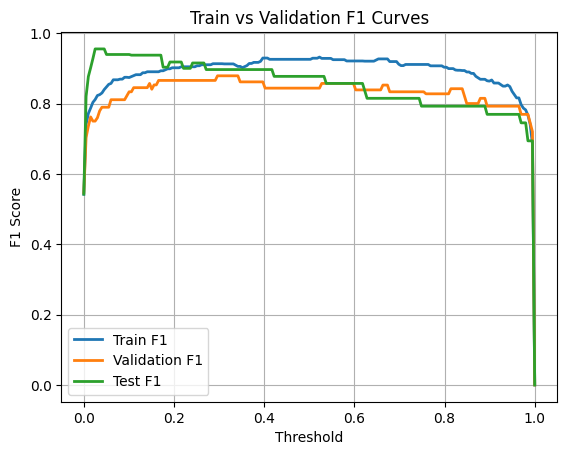

In [21]:
plt.plot(thresholds, f1_tr_curve, label="Train F1", linewidth=2)
plt.plot(thresholds, f1_val_curve, label="Validation F1", linewidth=2)
plt.plot(thresholds, f1_test_curve, label="Test F1", linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 Curves")
plt.legend()
plt.grid(True)
plt.show()

## Probability calibration

In [24]:
# Predict logits
logits_tr = model.predict_logits(x_tr_std)
logits_val = model.predict_logits(x_val_std)
logits_test = model.predict_logits(x_test_std)

In [25]:
cal = Calibrator(method="temperature")
cal.fit(logits_val, y_val_t)

probs_tr_cal = cal.predict_proba(logits_tr)
probs_val_cal = cal.predict_proba(logits_val)
probs_test_cal = cal.predict_proba(logits_test)

In [28]:
# Compute brier score - non calibrated probs
bss_tr = calculate_brier_metrics(y_tr, probs_tr)
bss_val = calculate_brier_metrics(y_val, probs_val)
bss_test = calculate_brier_metrics(y_test, probs_test)
print("Non-calibrated probabilities")
print("- Train bss:", round(bss_tr["bss"], 4))
print("- Val bss:", round(bss_val["bss"], 4))
print("- Test bss:", round(bss_test["bss"], 4))

# Compute brier score - calibrated probs
bss_tr = calculate_brier_metrics(y_tr, probs_tr_cal)
bss_val = calculate_brier_metrics(y_val, probs_val_cal)
bss_test = calculate_brier_metrics(y_test, probs_test_cal)
print()
print("Calibrated probabilities")
print("- Train bss:", round(bss_tr["bss"], 4))
print("- Val bss:", round(bss_val["bss"], 4))
print("- Test bss:", round(bss_test["bss"], 4))

Non-calibrated probabilities
- Train bss: 0.8127
- Val bss: 0.6618
- Test bss: 0.739

Calibrated probabilities
- Train bss: 0.8121
- Val bss: 0.6534
- Test bss: 0.7297


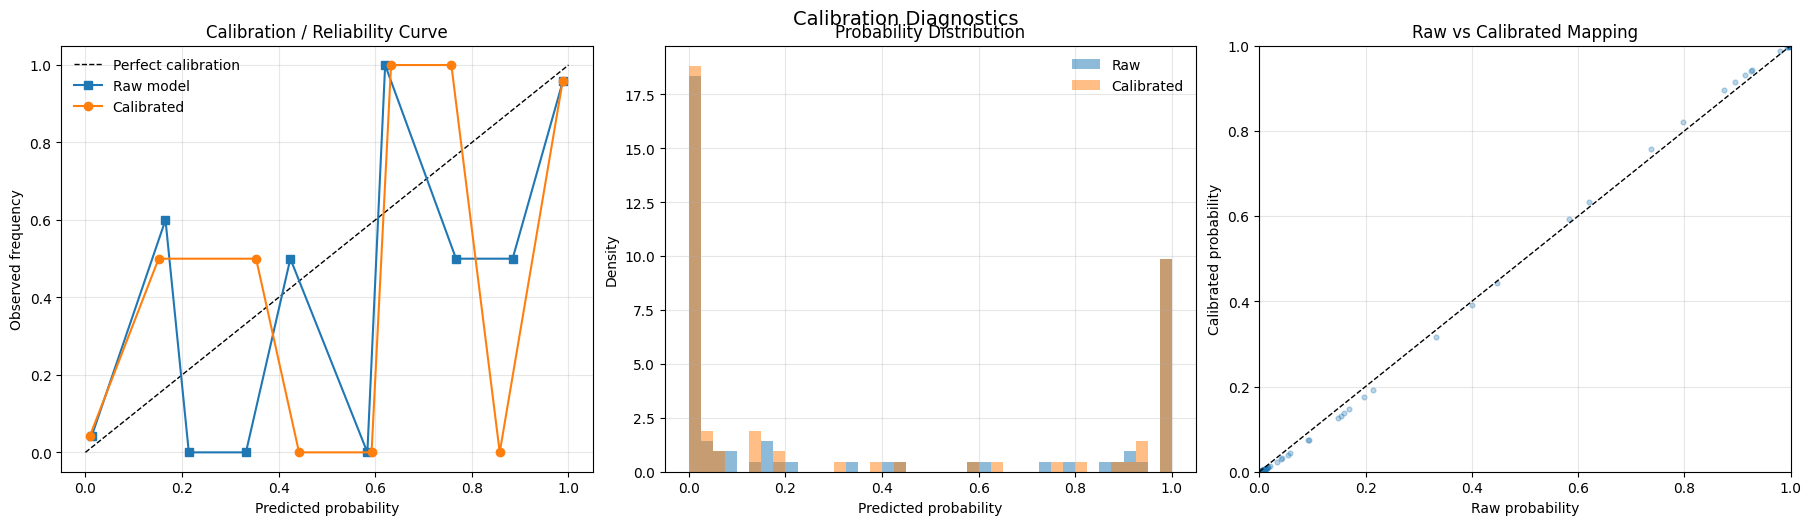

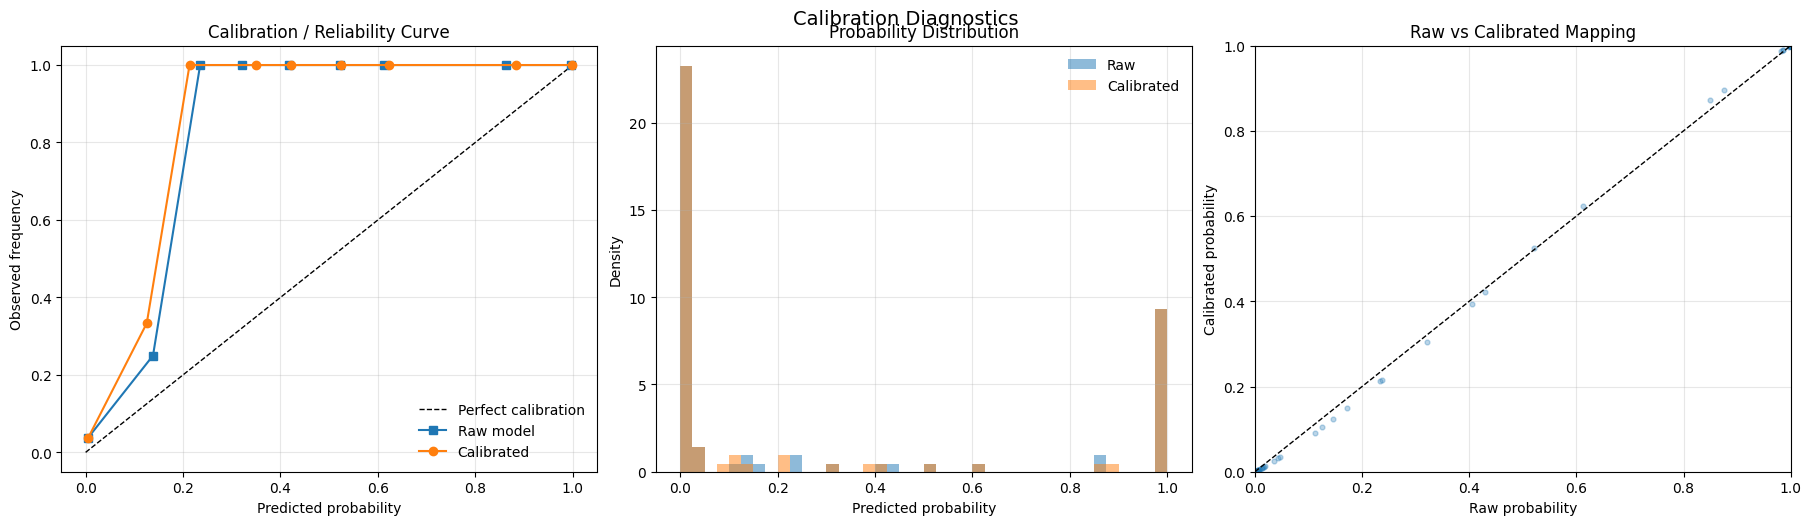

In [17]:
fig, axes = calibration_diagnostics(y_val, probs_val, probs_val_cal, n_bins=10, bins=40)
fig, axes = calibration_diagnostics(y_test, probs_test, probs_test_cal, n_bins=10, bins=40)
plt.show()

## Partial dependencies

In [27]:
FEATURE_NAME = "mean radius"
MODE = "pdp"

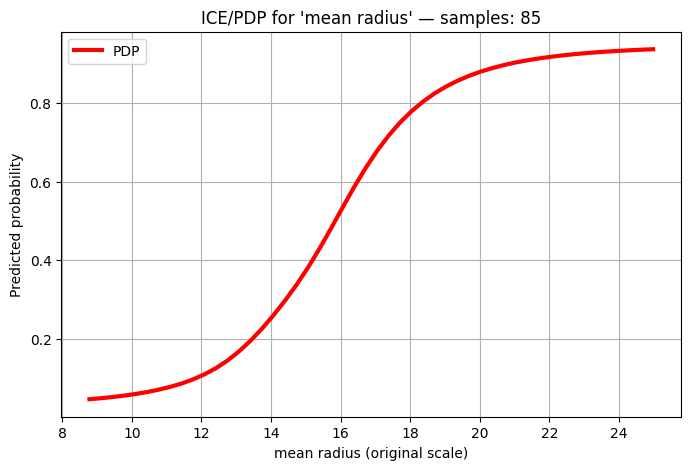

In [28]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_val.values,
    X_std=x_val_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=False,
)

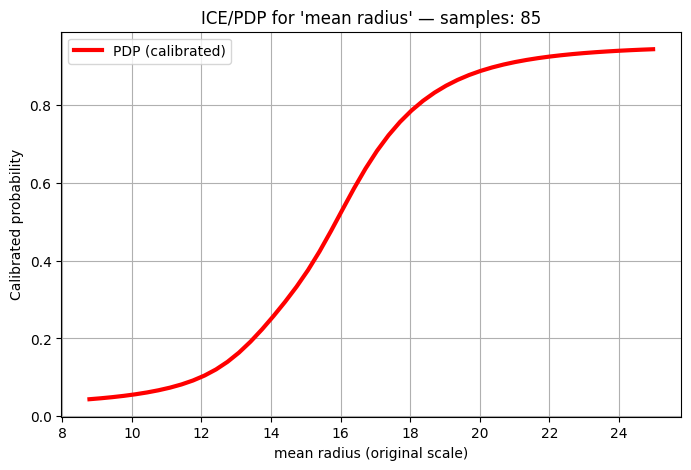

In [29]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_val.values,
    X_std=x_val_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=True,
)

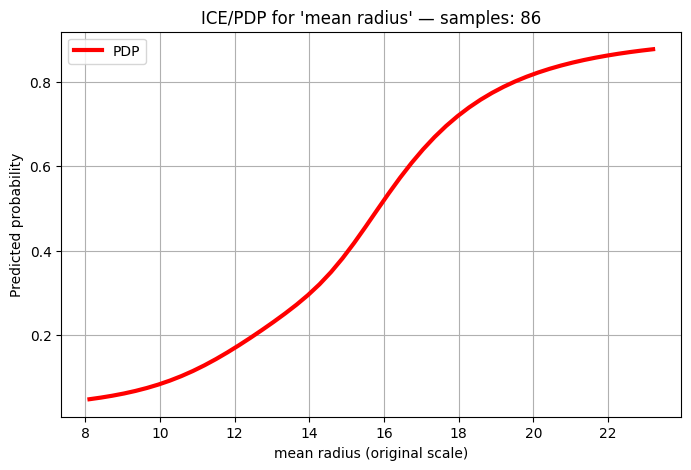

In [30]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_test.values,
    X_std=x_test_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=False,
)

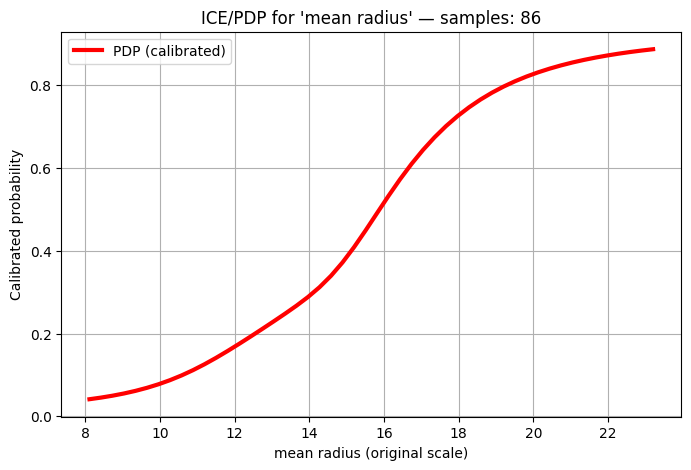

In [31]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_test.values,
    X_std=x_test_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=True,
)